In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.model_selection import cross_val_score, GroupKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import label_binarize

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
df = pd.read_csv("../data/books.csv", on_bad_lines="skip")
print("rows:", len(df))
print("columns:", df.shape[1])
df.head()

rows: 11123
columns: 12


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher;;;
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9.780440e+12,eng,652.0,2095690.0,27591.0,9/16/2006,Scholastic Inc.;;;
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9.780439e+12,eng,870.0,2153167.0,29221.0,9/1/2004,Scholastic Inc.;;;
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9.780440e+12,eng,352.0,6333.0,244.0,11/1/2003,Scholastic;;;
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.780440e+12,eng,435.0,2339585.0,36325.0,5/1/2004,Scholastic Inc.;;;
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9.780440e+12,eng,2690.0,41428.0,164.0,9/13/2004,Scholastic;;;


In [4]:
df.columns = df.columns.str.strip()
print(list(df.columns))

['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13', 'language_code', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher;;;']


In [5]:
df = df.rename(columns={"publisher;;;": "publisher"})
df["publisher"] = df["publisher"].str.replace(";;;", "", regex=False)
df[["publisher"]].head()

,publisher
0,Scholastic Inc.
1,Scholastic Inc.
2,Scholastic
3,Scholastic Inc.
4,Scholastic


In [6]:
is_real_id = df["bookID"].astype(str).str.isdigit()
print("rows before:", len(df))
df = df[is_real_id].copy()
print("rows after removing broken rows:", len(df))

rows before: 11123
rows after removing broken rows: 11094


In [7]:
df["title"] = df["title"].str.strip()
df["authors"] = df["authors"].str.strip()
df["publisher"] = df["publisher"].str.strip()
df["language_code"] = df["language_code"].str.strip()

In [8]:
df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
df["num_pages"] = pd.to_numeric(df["num_pages"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")
df["text_reviews_count"] = pd.to_numeric(df["text_reviews_count"], errors="coerce")
df.dtypes

bookID                 object
title                  object
authors                object
average_rating        float64
isbn                   object
isbn13                float64
language_code          object
num_pages             float64
ratings_count         float64
text_reviews_count    float64
publication_date       object
publisher              object
dtype: object

In [9]:
df["pub_date"] = pd.to_datetime(df["publication_date"], format="%m/%d/%Y", errors="coerce")
df["pub_year"] = df["pub_date"].dt.year
print("dates that could not be read:", int(df["pub_date"].isna().sum()))

dates that could not be read: 2


In [10]:
print("books with zero ratings:", int((df["ratings_count"] == 0).sum()))
df = df[df["ratings_count"] > 0].copy()
print("rows after removing zero-rating books:", len(df))

books with zero ratings: 78
rows after removing zero-rating books: 11016


In [11]:
not_a_book = df["authors"].str.upper().str.contains("NOT A BOOK", na=False)
print("not a book records:", int(not_a_book.sum()))
df = df[~not_a_book].copy()
print("rows after removing them:", len(df))

not a book records: 4
rows after removing them: 11012


In [12]:
df["num_pages"] = df["num_pages"].replace(0, np.nan)
print("books with unknown page count:", int(df["num_pages"].isna().sum()))

books with unknown page count: 72


In [13]:
df = df.dropna(subset=["average_rating"]).reset_index(drop=True)
df["first_author"] = df["authors"].str.split("/").str[0].str.strip()
print("final clean shape:", df.shape)
df.head()

final clean shape: (11012, 15)


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,pub_date,pub_year,first_author
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9.780440e+12,eng,652.0,2095690.0,27591.0,9/16/2006,Scholastic Inc.,2006-09-16,2006.0,J.K. Rowling
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9.780439e+12,eng,870.0,2153167.0,29221.0,9/1/2004,Scholastic Inc.,2004-09-01,2004.0,J.K. Rowling
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9.780440e+12,eng,352.0,6333.0,244.0,11/1/2003,Scholastic,2003-11-01,2003.0,J.K. Rowling
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.780440e+12,eng,435.0,2339585.0,36325.0,5/1/2004,Scholastic Inc.,2004-05-01,2004.0,J.K. Rowling
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9.780440e+12,eng,2690.0,41428.0,164.0,9/13/2004,Scholastic,2004-09-13,2004.0,J.K. Rowling


In [14]:
overview = pd.DataFrame()
overview["dtype"] = df.dtypes.astype(str)
overview["unique_values"] = df.nunique()
overview["percent_missing"] = (df.isnull().mean() * 100).round(2)
overview

,dtype,unique_values,percent_missing
bookID,object,11012,0.00
title,object,10241,0.00
authors,object,6562,0.00
average_rating,float64,208,0.00
isbn,object,11012,0.00
isbn13,float64,11012,0.00
language_code,object,26,0.00
num_pages,float64,993,0.65
ratings_count,float64,5290,0.00
text_reviews_count,float64,1822,0.00


In [15]:
df.describe().round(2)

,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,pub_date,pub_year
count,11012.00,1.101200e+04,10940.00,11012.00,11012.00,11010,11010.00
mean,3.94,9.759664e+12,339.23,18121.44,547.35,2000-09-06 08:20:39.891008128,2000.19
min,1.00,8.987060e+09,1.00,1.00,0.00,1900-01-01 00:00:00,1900.00
25%,3.78,9.780345e+12,197.00,111.00,9.00,1998-08-08 12:00:00,1998.00
50%,3.96,9.780573e+12,302.00,768.00,48.00,2003-03-03 00:00:00,2003.00
75%,4.14,9.780872e+12,416.00,5082.75,242.00,2005-10-01 00:00:00,2005.00
max,5.00,9.790008e+12,6576.00,4597666.00,94265.00,2020-03-31 00:00:00,2020.00
std,0.29,4.451977e+11,240.33,113050.57,2589.02,NaN,8.21


In [16]:
print("exact duplicate rows:", int(df.duplicated().sum()))
print("same title and author pairs:", int(df.duplicated(subset=["title", "authors"]).sum()))

exact duplicate rows: 0
same title and author pairs: 308


In [17]:
print("text reviews never exceed ratings:", bool((df["text_reviews_count"] <= df["ratings_count"]).all()))
print("rows with missing page count:", int(df["num_pages"].isna().sum()))
print("duplicate isbn values:", int(df["isbn"].duplicated().sum()))

text reviews never exceed ratings: True
rows with missing page count: 72
duplicate isbn values: 0


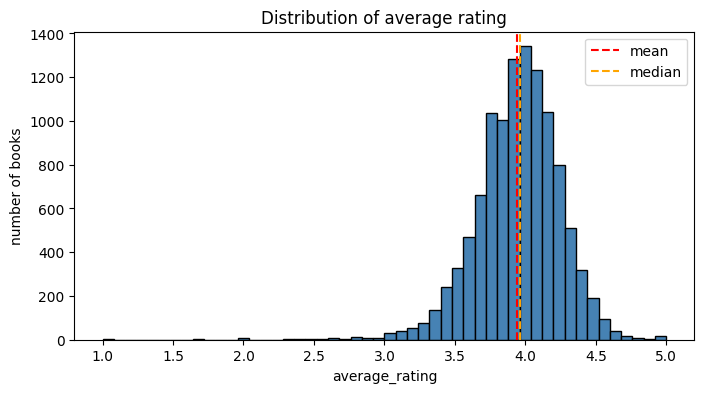

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(df["average_rating"], bins=50, color="steelblue", edgecolor="black")
plt.axvline(df["average_rating"].mean(), color="red", linestyle="--", label="mean")
plt.axvline(df["average_rating"].median(), color="orange", linestyle="--", label="median")
plt.xlabel("average_rating")
plt.ylabel("number of books")
plt.title("Distribution of average rating")
plt.legend()
plt.show()

In [19]:
rated_4_or_more = (df["average_rating"] >= 4).sum()
rated_3_to_4 = ((df["average_rating"] >= 3) & (df["average_rating"] < 4)).sum()
rated_below_3 = (df["average_rating"] < 3).sum()
print("rated 4.0 or more:", int(rated_4_or_more))
print("rated 3.0 to 4.0:", int(rated_3_to_4))
print("rated below 3.0:", int(rated_below_3))

rated 4.0 or more: 4915
rated 3.0 to 4.0: 6042
rated below 3.0: 55


In [20]:
five_star = df[df["average_rating"] == 5.0]
print("books with a perfect 5.0 rating:", len(five_star))
print("their median ratings_count:", int(five_star["ratings_count"].median()))
print("overall median ratings_count:", int(df["ratings_count"].median()))

books with a perfect 5.0 rating: 17
their median ratings_count: 2
overall median ratings_count: 768


In [21]:
print(df["num_pages"].describe().round(1))
print("books over 1000 pages:", int((df["num_pages"] >= 1000).sum()))

count    10940.0
mean       339.2
std        240.3
min          1.0
25%        197.0
50%        302.0
75%        416.0
max       6576.0
Name: num_pages, dtype: float64
books over 1000 pages: 215


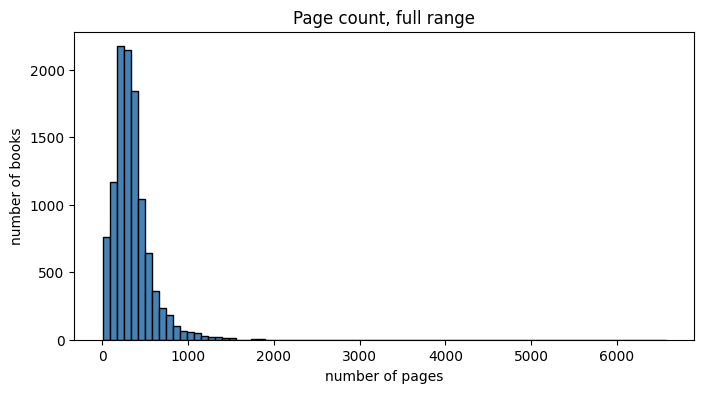

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(df["num_pages"].dropna(), bins=80, color="steelblue", edgecolor="black")
plt.xlabel("number of pages")
plt.ylabel("number of books")
plt.title("Page count, full range")
plt.show()

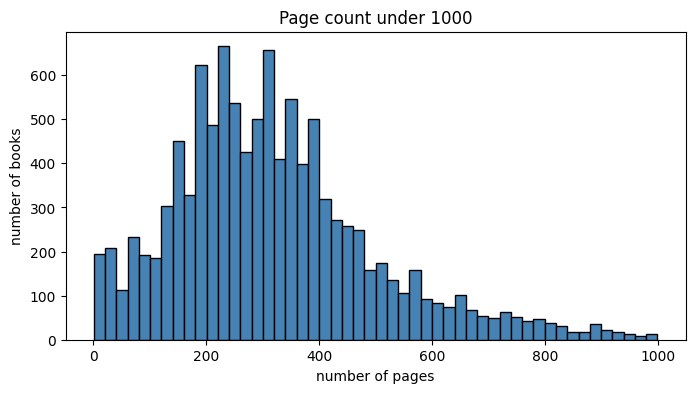

In [23]:
short_books = df[df["num_pages"] < 1000]
plt.figure(figsize=(8, 4))
plt.hist(short_books["num_pages"].dropna(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("number of pages")
plt.ylabel("number of books")
plt.title("Page count under 1000")
plt.show()

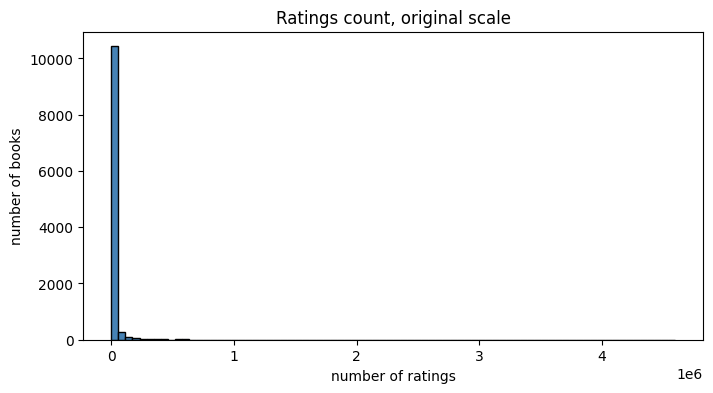

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(df["ratings_count"], bins=80, color="steelblue", edgecolor="black")
plt.xlabel("number of ratings")
plt.ylabel("number of books")
plt.title("Ratings count, original scale")
plt.show()

count      11012.0
mean       18121.0
std       113051.0
min            1.0
25%          111.0
50%          768.0
75%         5083.0
max      4597666.0
Name: ratings_count, dtype: float64


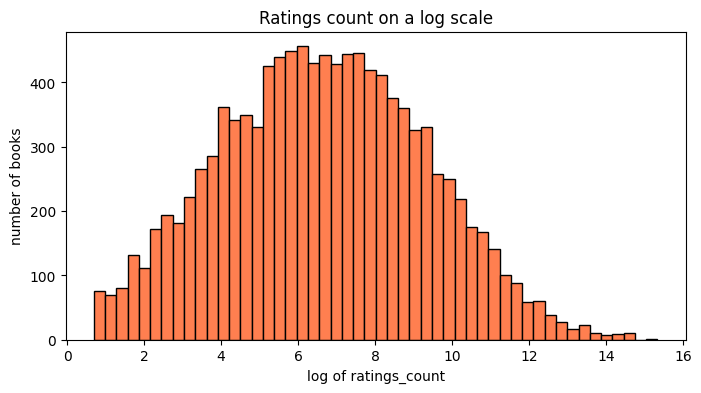

In [25]:
print(df["ratings_count"].describe().round(0))
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["ratings_count"]), bins=50, color="coral", edgecolor="black")
plt.xlabel("log of ratings_count")
plt.ylabel("number of books")
plt.title("Ratings count on a log scale")
plt.show()

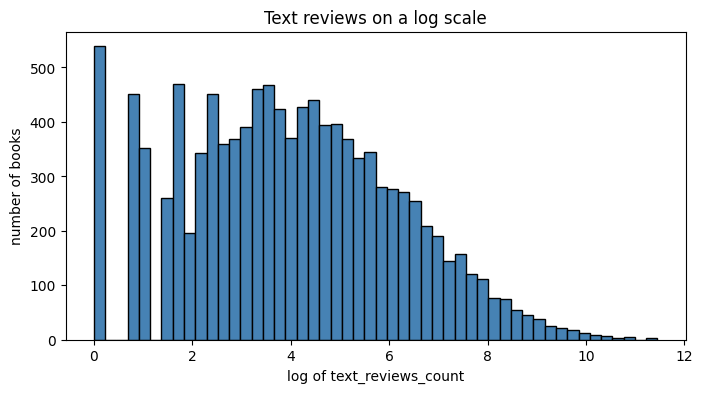

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["text_reviews_count"]), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("log of text_reviews_count")
plt.ylabel("number of books")
plt.title("Text reviews on a log scale")
plt.show()

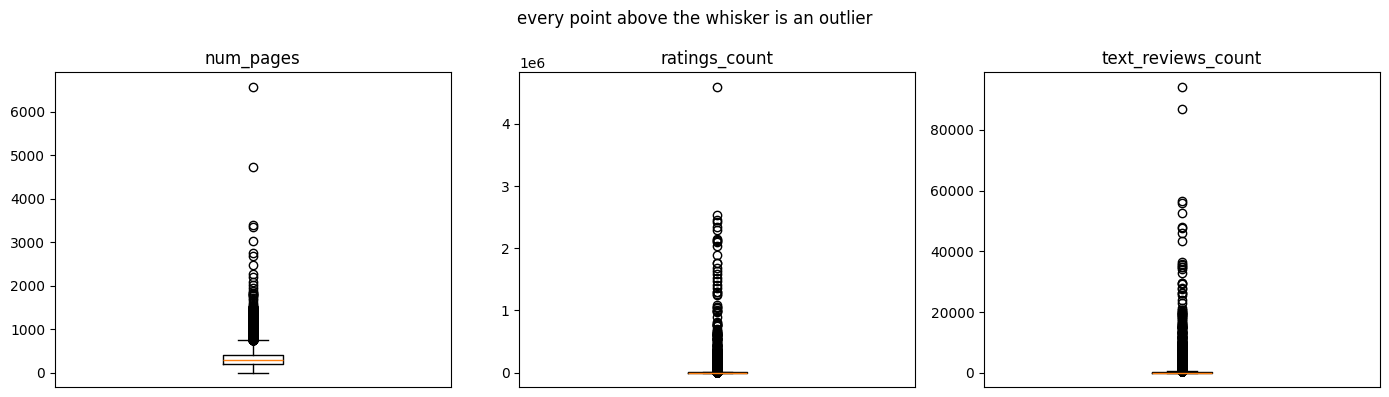

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].boxplot(df["num_pages"].dropna())
axes[0].set_title("num_pages")
axes[0].set_xticks([])
axes[1].boxplot(df["ratings_count"].dropna())
axes[1].set_title("ratings_count")
axes[1].set_xticks([])
axes[2].boxplot(df["text_reviews_count"].dropna())
axes[2].set_title("text_reviews_count")
axes[2].set_xticks([])
plt.suptitle("every point above the whisker is an outlier")
plt.tight_layout()
plt.show()

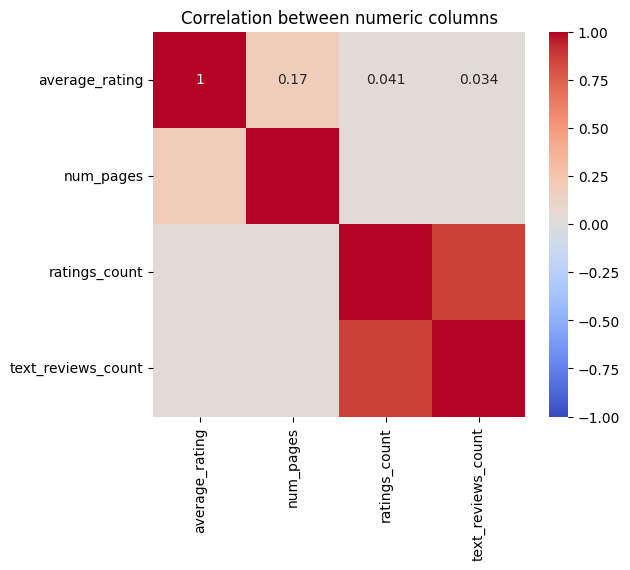

In [28]:
numeric_columns = ["average_rating", "num_pages", "ratings_count", "text_reviews_count"]
correlation = df[numeric_columns].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric columns")
plt.show()

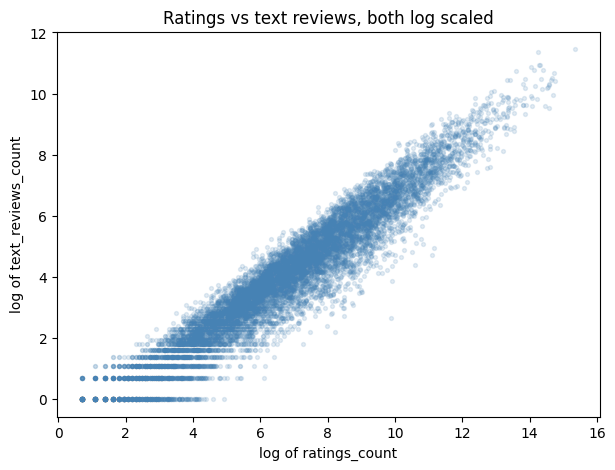

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(np.log1p(df["ratings_count"]), np.log1p(df["text_reviews_count"]), alpha=0.15, s=8, color="steelblue")
plt.xlabel("log of ratings_count")
plt.ylabel("log of text_reviews_count")
plt.title("Ratings vs text reviews, both log scaled")
plt.show()

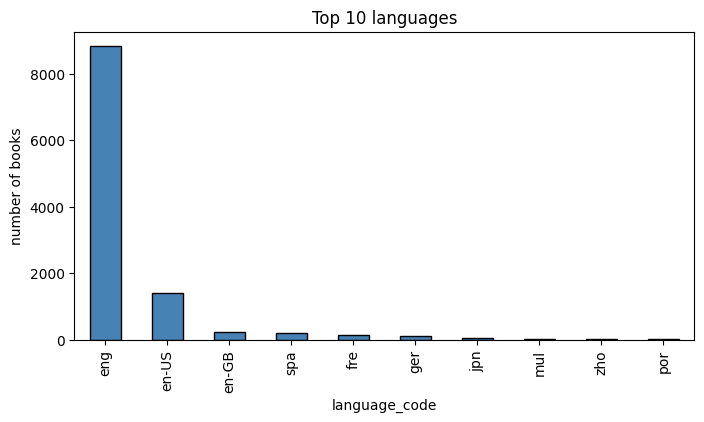

In [30]:
top_languages = df["language_code"].value_counts().head(10)
plt.figure(figsize=(8, 4))
top_languages.plot.bar(color="steelblue", edgecolor="black")
plt.xlabel("language_code")
plt.ylabel("number of books")
plt.title("Top 10 languages")
plt.show()

                mean  count
language_code              
fre            3.971    140
ger            3.946     96
eng            3.945   8820
en-GB          3.925    213
spa            3.924    212
en-US          3.916   1403


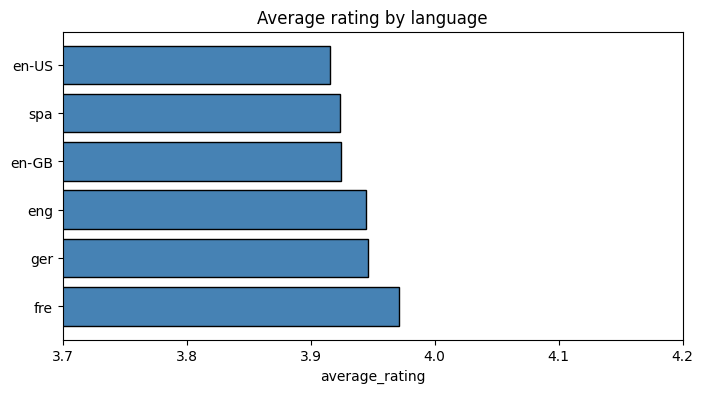

In [31]:
lang_stats = df.groupby("language_code")["average_rating"].agg(["mean", "count"])
lang_stats = lang_stats[lang_stats["count"] >= 50].sort_values("mean", ascending=False).head(6)
print(lang_stats.round(3))
plt.figure(figsize=(8, 4))
plt.barh(lang_stats.index, lang_stats["mean"], color="steelblue", edgecolor="black")
plt.xlim(3.7, 4.2)
plt.xlabel("average_rating")
plt.title("Average rating by language")
plt.show()

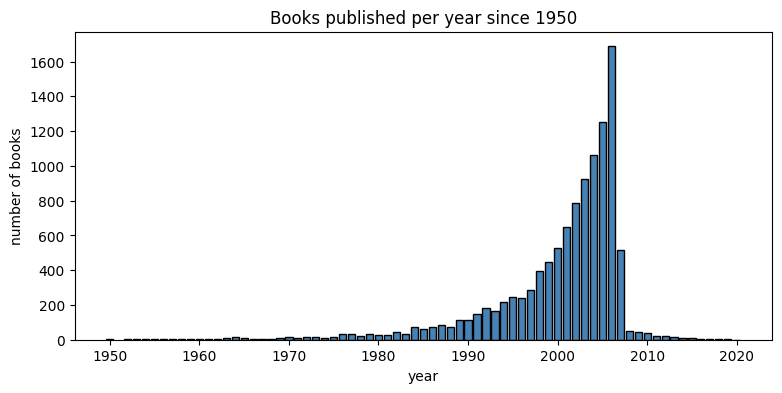

In [32]:
books_per_year = df["pub_year"].dropna().astype(int).value_counts().sort_index()
books_per_year = books_per_year[books_per_year.index >= 1950]
plt.figure(figsize=(9, 4))
plt.bar(books_per_year.index, books_per_year.values, color="steelblue", edgecolor="black")
plt.xlabel("year")
plt.ylabel("number of books")
plt.title("Books published per year since 1950")
plt.show()

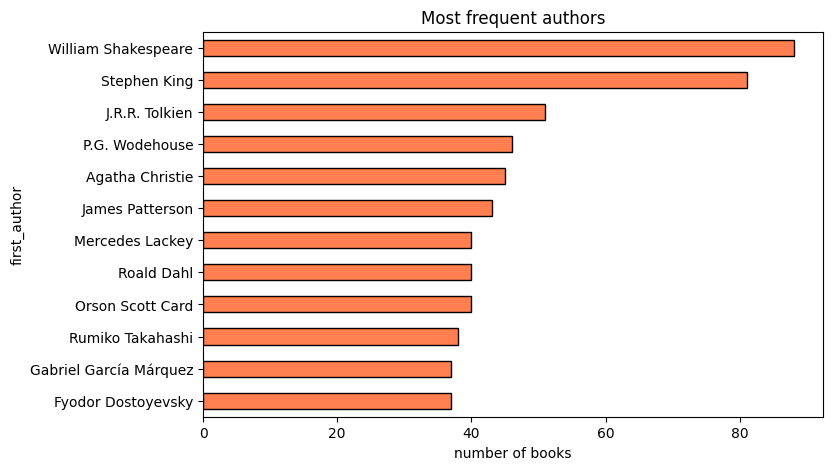

In [33]:
top_authors = df["first_author"].value_counts().head(12)
plt.figure(figsize=(8, 5))
top_authors.sort_values().plot.barh(color="coral", edgecolor="black")
plt.xlabel("number of books")
plt.title("Most frequent authors")
plt.show()

title
The Brothers Karamazov        9
The Iliad                     9
'Salem's Lot                  8
The Odyssey                   8
Anna Karenina                 8
Gulliver's Travels            8
The Picture of Dorian Gray    7
A Midsummer Night's Dream     7
Collected Stories             6
Romeo and Juliet              6
Macbeth                       6
The Histories                 6
Sense and Sensibility         6
The Secret Garden             6
The Great Gatsby              6
Name: count, dtype: int64


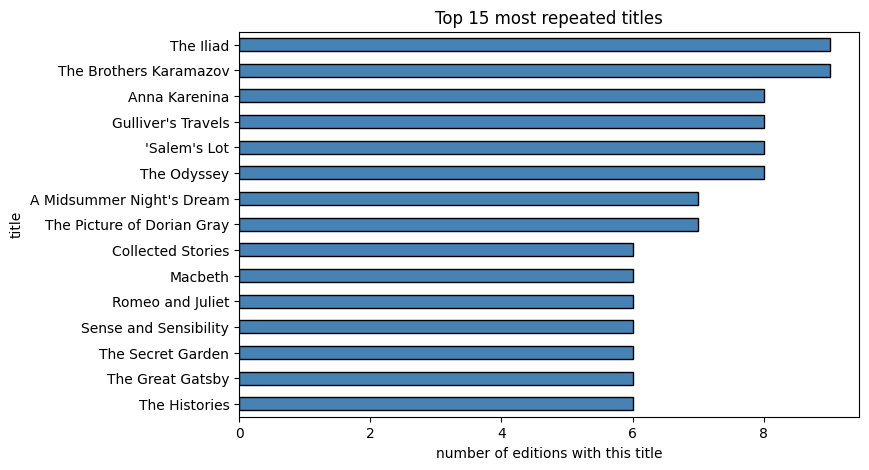

In [34]:
top_repeated = df["title"].value_counts().head(15)
print(top_repeated)
plt.figure(figsize=(8, 5))
top_repeated.sort_values().plot.barh(color="steelblue", edgecolor="black")
plt.xlabel("number of editions with this title")
plt.title("Top 15 most repeated titles")
plt.show()

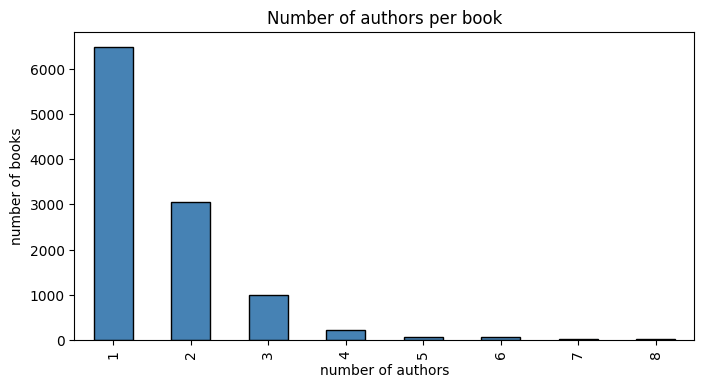

In [35]:
df["num_authors"] = df["authors"].str.count("/") + 1
author_counts = df["num_authors"].value_counts().sort_index().head(8)
plt.figure(figsize=(8, 4))
author_counts.plot.bar(color="steelblue", edgecolor="black")
plt.xlabel("number of authors")
plt.ylabel("number of books")
plt.title("Number of authors per book")
plt.show()

num_authors
1    3.920
2    3.966
3    3.998
4    4.056
5    4.006
6    3.997
Name: average_rating, dtype: float64


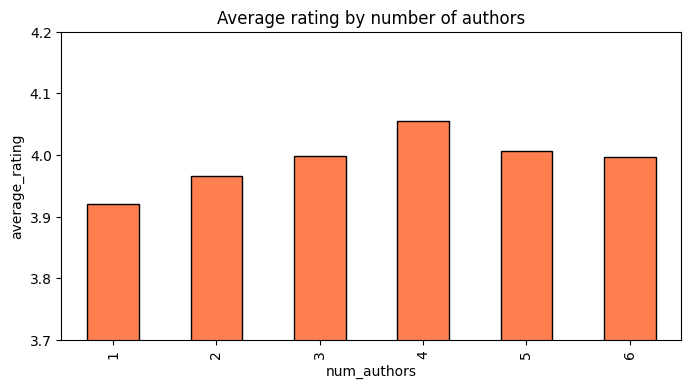

In [36]:
rating_by_authors = df.groupby("num_authors")["average_rating"].mean().head(6)
print(rating_by_authors.round(3))
plt.figure(figsize=(8, 4))
rating_by_authors.plot.bar(color="coral", edgecolor="black")
plt.ylim(3.7, 4.2)
plt.ylabel("average_rating")
plt.title("Average rating by number of authors")
plt.show()

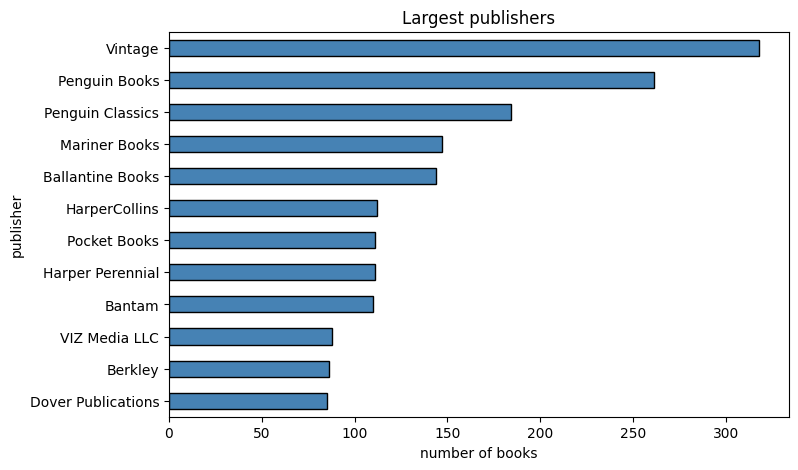

In [37]:
top_publishers = df["publisher"].value_counts().head(12)
plt.figure(figsize=(8, 5))
top_publishers.sort_values().plot.barh(color="steelblue", edgecolor="black")
plt.xlabel("number of books")
plt.title("Largest publishers")
plt.show()

                               mean  count
publisher                                 
Library of America            4.263     52
VIZ Media LLC                 4.243     88
Del Rey                       4.042     80
HarperCollins                 4.037    112
Puffin Books                  4.019     50
W. W. Norton  Company         4.004     68
Modern Library                3.978     81
Penguin                       3.957     58
Dover Publications            3.954     85
Signet                        3.945     65
Penguin Classics              3.945    184
Oxford University Press  USA  3.936     74


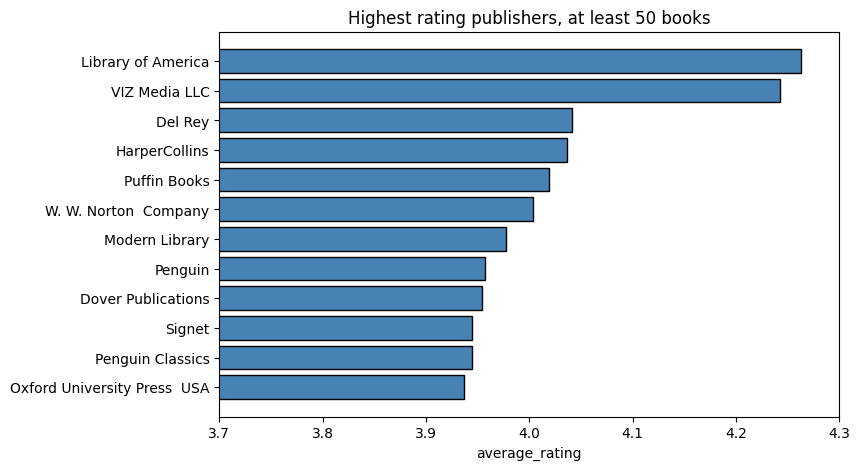

In [38]:
publisher_stats = df.groupby("publisher")["average_rating"].agg(["mean", "count"])
publisher_stats = publisher_stats[publisher_stats["count"] >= 50].sort_values("mean", ascending=False).head(12)
print(publisher_stats.round(3))
plt.figure(figsize=(8, 5))
plt.barh(publisher_stats.index[::-1], publisher_stats["mean"][::-1], color="steelblue", edgecolor="black")
plt.xlim(3.7, 4.3)
plt.xlabel("average_rating")
plt.title("Highest rating publishers, at least 50 books")
plt.show()

                     mean  count
first_author                    
J.R.R. Tolkien      4.223     51
Fyodor Dostoyevsky  4.197     37
C.S. Lewis          4.192     33
Rumiko Takahashi    4.190     38
P.G. Wodehouse      4.165     46
Jane Austen         4.157     33
Terry Pratchett     4.115     31
Roald Dahl          4.060     40
Stephen King        4.004     81
Mercedes Lackey     4.003     40
Mark Twain          3.969     31
Agatha Christie     3.958     45


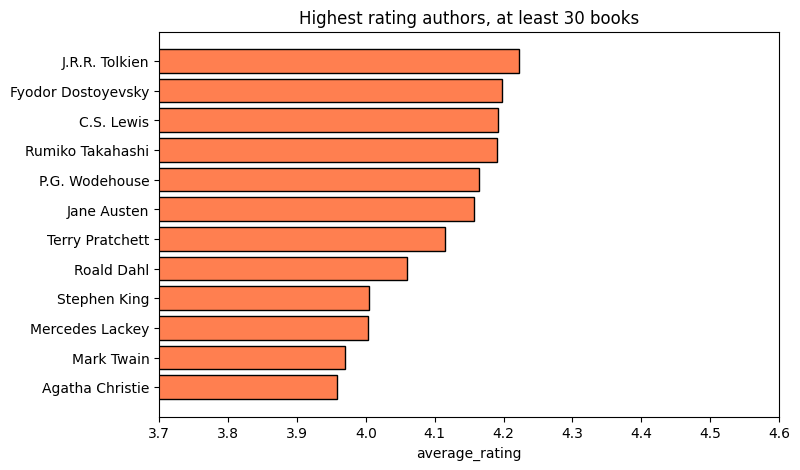

In [39]:
author_stats = df.groupby("first_author")["average_rating"].agg(["mean", "count"])
author_stats = author_stats[author_stats["count"] >= 30].sort_values("mean", ascending=False).head(12)
print(author_stats.round(3))
plt.figure(figsize=(8, 5))
plt.barh(author_stats.index[::-1], author_stats["mean"][::-1], color="coral", edgecolor="black")
plt.xlim(3.7, 4.6)
plt.xlabel("average_rating")
plt.title("Highest rating authors, at least 30 books")
plt.show()

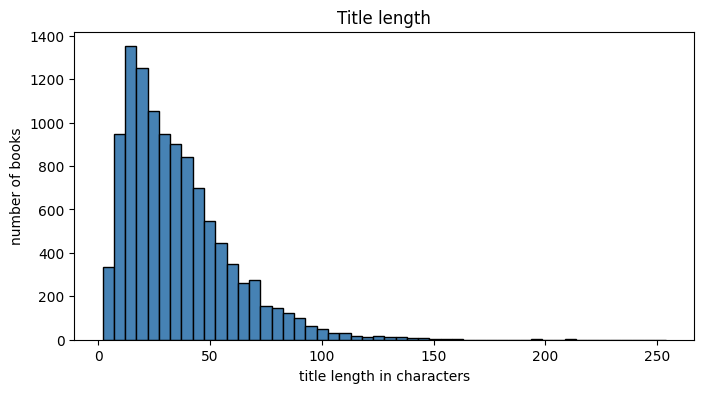

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(df["title"].str.len(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("title length in characters")
plt.ylabel("number of books")
plt.title("Title length")
plt.show()

popularity_group
very low     3.903
low          3.934
medium       3.943
high         3.953
very high    3.984
Name: average_rating, dtype: float64


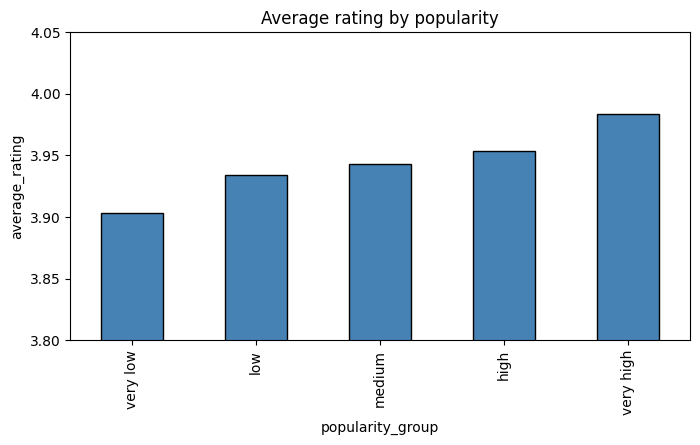

In [41]:
df["popularity_group"] = pd.qcut(df["ratings_count"], 5, labels=["very low", "low", "medium", "high", "very high"])
rating_by_popularity = df.groupby("popularity_group", observed=True)["average_rating"].mean()
print(rating_by_popularity.round(3))
plt.figure(figsize=(8, 4))
rating_by_popularity.plot.bar(color="steelblue", edgecolor="black")
plt.ylim(3.8, 4.05)
plt.ylabel("average_rating")
plt.title("Average rating by popularity")
plt.show()

In [42]:
popular = df[df["ratings_count"] >= 1000]
print("books with at least 1000 ratings:", len(popular))
print("their average rating:", round(popular["average_rating"].mean(), 3))
print("all books average rating:", round(df["average_rating"].mean(), 3))

books with at least 1000 ratings: 5109
their average rating: 3.964
all books average rating: 3.943


length_group
under 200      3.937
200 to 400     3.901
400 to 600     3.977
600 to 1000    4.070
over 1000      4.224
Name: average_rating, dtype: float64


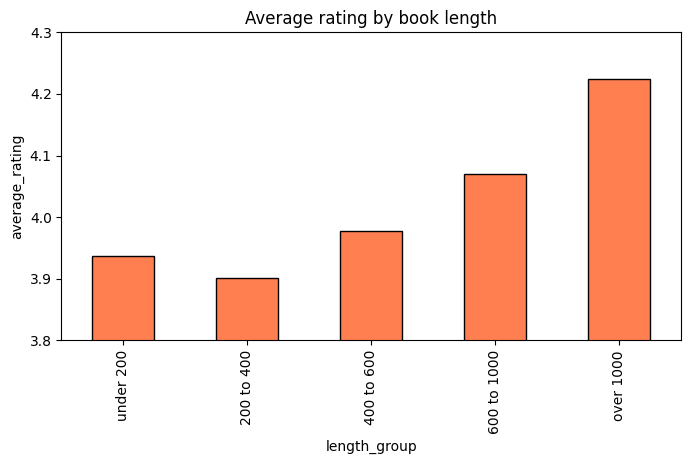

In [43]:
df["length_group"] = pd.cut(df["num_pages"], bins=[0, 200, 400, 600, 1000, 10000],
                            labels=["under 200", "200 to 400", "400 to 600", "600 to 1000", "over 1000"])
rating_by_length = df.groupby("length_group", observed=True)["average_rating"].mean()
print(rating_by_length.round(3))
plt.figure(figsize=(8, 4))
rating_by_length.plot.bar(color="coral", edgecolor="black")
plt.ylim(3.8, 4.3)
plt.ylabel("average_rating")
plt.title("Average rating by book length")
plt.show()

decade
1950    3.991
1960    3.959
1970    3.961
1980    3.979
1990    3.953
2000    3.936
2010    3.995
Name: average_rating, dtype: float64


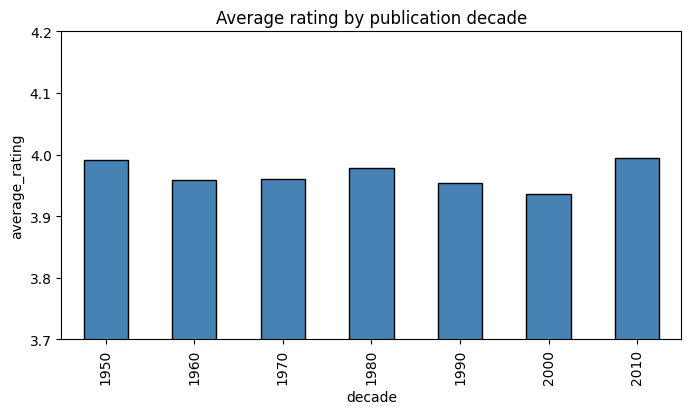

In [44]:
decade_books = df[df["pub_year"].between(1950, 2010)].copy()
decade_books["decade"] = (decade_books["pub_year"] // 10 * 10).astype(int)
rating_by_decade = decade_books.groupby("decade")["average_rating"].mean()
print(rating_by_decade.round(3))
plt.figure(figsize=(8, 4))
rating_by_decade.plot.bar(color="steelblue", edgecolor="black")
plt.ylim(3.7, 4.2)
plt.ylabel("average_rating")
plt.title("Average rating by publication decade")
plt.show()

In [45]:
df["title_core"] = df["title"].str.lower()
df["title_core"] = df["title_core"].str.replace(r"\(.*?\)|\[.*?\]", " ", regex=True)
df["title_core"] = df["title_core"].str.replace(r"[^a-z0-9 ]", " ", regex=True)
df["title_core"] = df["title_core"].str.replace(r"\s+", " ", regex=True).str.strip()
df["work_key"] = df["title_core"] + " :: " + df["first_author"].str.lower().fillna("")
df[["title", "work_key"]].head()

,title,work_key
0,Harry Potter and the Half-Blood Prince (Harry ...,harry potter and the half blood prince :: j.k....
1,Harry Potter and the Order of the Phoenix (Har...,harry potter and the order of the phoenix :: j...
2,Harry Potter and the Chamber of Secrets (Harry...,harry potter and the chamber of secrets :: j.k...
3,Harry Potter and the Prisoner of Azkaban (Harr...,harry potter and the prisoner of azkaban :: j....
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,harry potter boxed set books 1 5 :: j.k. rowling


In [46]:
df_sorted = df.sort_values("ratings_count", ascending=False)
works = df_sorted.drop_duplicates(subset="work_key", keep="first").copy()
works = works.reset_index(drop=True)
print("editions:", len(df))
print("works after keeping the most rated edition of each book:", len(works))

editions: 11012
works after keeping the most rated edition of each book: 10157


In [47]:
edition_counts = df["work_key"].value_counts()
works["n_editions"] = works["work_key"].map(edition_counts)
print("books that exist in more than one edition:", int((works["n_editions"] > 1).sum()))

books that exist in more than one edition: 547


In [48]:
works["num_pages_missing"] = works["num_pages"].isna().astype(int)
print("books with a missing page count:", int(works["num_pages_missing"].sum()))

books with a missing page count: 53


rating cut points: [1.   3.84 4.07 5.  ]
rating_class
low rating       3453
high rating      3357
medium rating    3347
Name: count, dtype: int64


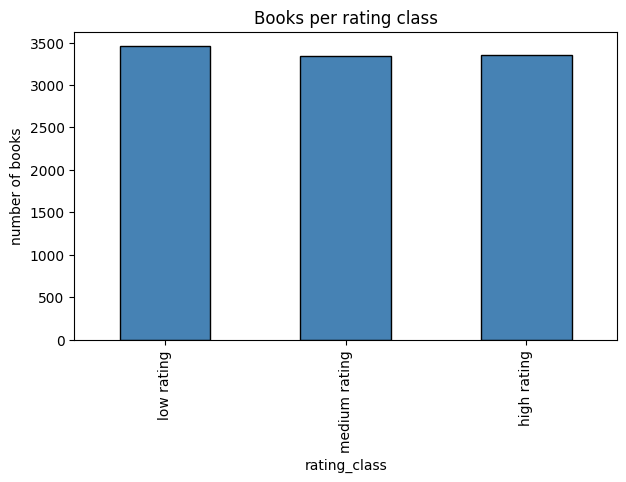

In [49]:
class_names = ["low rating", "medium rating", "high rating"]
works["rating_class"], rating_bins = pd.qcut(works["average_rating"], q=3, labels=class_names, retbins=True)
class_codes = {"low rating": 0, "medium rating": 1, "high rating": 2}
works["target"] = works["rating_class"].map(class_codes)
print("rating cut points:", rating_bins.round(3))
print(works["rating_class"].value_counts())
plt.figure(figsize=(7, 4))
works["rating_class"].value_counts().reindex(class_names).plot.bar(color="steelblue", edgecolor="black")
plt.ylabel("number of books")
plt.title("Books per rating class")
plt.show()

In [50]:
works["title_word_count"] = works["title"].str.split().str.len()
works["title_char_len"] = works["title"].str.len()
works["has_subtitle"] = works["title"].str.contains(":", regex=False).astype(int)
works["has_number_in_title"] = works["title"].str.contains(r"\d", regex=True).astype(int)
works[["title_word_count", "title_char_len", "has_subtitle", "has_number_in_title"]].head()

,title_word_count,title_char_len,has_subtitle,has_number_in_title
0,3,23,0,1
1,7,35,0,0
2,5,22,0,0
3,6,36,0,1
4,10,59,0,1


In [51]:
works["series_number"] = works["title"].str.extract(r"(\d+)\)\s*$")[0]
works["series_number"] = works["series_number"].fillna(0).astype(int)
works["is_series"] = (works["series_number"] > 0).astype(int)
print("books that are part of a numbered series:", int(works["is_series"].sum()))

books that are part of a numbered series: 2252


In [52]:
works["is_collection"] = works["title"].str.lower().str.contains("boxed set|box set|omnibus|collection|anthology").astype(int)
works["is_study_guide"] = works["title"].str.lower().str.contains("cliffsnotes|sparknotes|spark notes|study guide").astype(int)
print("collections:", int(works["is_collection"].sum()))
print("study guides:", int(works["is_study_guide"].sum()))

collections: 82
study guides: 31


In [53]:
works["num_authors"] = works["authors"].str.count("/") + 1
works["num_authors"].value_counts().sort_index().head()

num_authors
1    6119
2    2738
3     866
4     199
5      55
Name: count, dtype: int64

In [54]:
REFERENCE_YEAR = 2021
works["pub_quarter"] = works["pub_date"].dt.quarter
works["book_age"] = REFERENCE_YEAR - works["pub_year"]
works[["pub_year", "pub_quarter", "book_age"]].head()

,pub_year,pub_quarter,book_age
0,2006.0,3.0,15.0
1,2002.0,3.0,19.0
2,2001.0,1.0,20.0
3,2006.0,2.0,15.0
4,2004.0,2.0,17.0


In [55]:
works["log_ratings_count"] = np.log1p(works["ratings_count"])
works["log_text_reviews"] = np.log1p(works["text_reviews_count"])
works["reviews_per_rating"] = (works["text_reviews_count"] / works["ratings_count"]).clip(0, 1)
works[["log_ratings_count", "log_text_reviews", "reviews_per_rating"]].head()

,log_ratings_count,log_text_reviews,reviews_per_rating
0,15.341060,11.453876,0.020503
1,14.744084,10.400377,0.012988
2,14.714490,10.680516,0.017703
3,14.698756,9.966650,0.008807
4,14.665485,10.500289,0.015526


In [56]:
works["lang_group"] = "other"
works.loc[works["language_code"].str.startswith("en"), "lang_group"] = "english"
works.loc[works["language_code"].isin(["spa", "fre", "ger", "jpn"]), "lang_group"] = works["language_code"]
works["lang_group"].value_counts()

lang_group
english    9643
spa         187
fre         128
ger          91
other        64
jpn          44
Name: count, dtype: int64

In [57]:
works["publisher_norm"] = works["publisher"].str.lower()
works["publisher_norm"] = works["publisher_norm"].str.replace(r"[^a-z0-9 ]", " ", regex=True)
works["publisher_norm"] = works["publisher_norm"].str.replace(r"\b(inc|ltd|llc|co|company|books|book|publishing|publishers|publications|press|group|the)\b", " ", regex=True)
works["publisher_norm"] = works["publisher_norm"].str.replace(r"\s+", " ", regex=True).str.strip()
print("publishers before cleaning:", works["publisher"].nunique())
print("publishers after cleaning:", works["publisher_norm"].nunique())

publishers before cleaning: 2169
publishers after cleaning: 1844


In [58]:
author_book_count = works["first_author"].value_counts()
works["author_book_count"] = works["first_author"].map(author_book_count)
publisher_book_count = works["publisher_norm"].value_counts()
works["publisher_book_count"] = works["publisher_norm"].map(publisher_book_count)
print(works[["author_book_count", "publisher_book_count"]].describe().round(1))

       author_book_count  publisher_book_count
count            10157.0               10157.0
mean                 8.1                  57.9
std                  9.7                  80.2
min                  1.0                   1.0
25%                  1.0                   6.0
50%                  5.0                  25.0
75%                 11.0                  73.0
max                 59.0                 319.0


In [59]:
author_mean_ratings = works.groupby("first_author")["ratings_count"].mean()
works["author_avg_ratings"] = np.log1p(works["first_author"].map(author_mean_ratings))
print(works["author_avg_ratings"].describe().round(2))

count    10157.00
mean         7.78
std          2.50
min          0.69
25%          6.25
50%          8.09
75%          9.55
max         15.34
Name: author_avg_ratings, dtype: float64


In [60]:
numeric_features = ["num_pages", "num_pages_missing", "num_authors", "title_word_count", "title_char_len",
                    "has_subtitle", "has_number_in_title", "is_series", "series_number",
                    "is_collection", "is_study_guide", "book_age", "pub_quarter", "n_editions",
                    "author_book_count", "publisher_book_count", "author_avg_ratings",
                    "log_ratings_count", "log_text_reviews", "reviews_per_rating"]
target_encode_features = ["first_author", "publisher_norm"]
onehot_features = ["lang_group"]
feature_columns = numeric_features + target_encode_features + onehot_features
print("total features:", len(feature_columns))

total features: 23


In [61]:
X = works[feature_columns]
y = works["target"].to_numpy()
print("number of feature columns:", len(feature_columns))
print("number of classes:", len(class_names))

number of feature columns: 23
number of classes: 3


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("training rows:", len(X_train), "test rows:", len(X_test))

training rows: 8125 test rows: 2032


In [63]:
impute_numbers = SimpleImputer(strategy="median")
encode_authors_publishers = TargetEncoder(target_type="multiclass", random_state=RANDOM_STATE)
encode_language = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(transformers=[
    ("numbers", impute_numbers, numeric_features),
    ("authors_publishers", encode_authors_publishers, target_encode_features),
    ("language", encode_language, onehot_features),
])
class_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

author_avg_ratings      0.1678
num_pages               0.0463
title_word_count        0.0246
publisher_book_count    0.0240
author_book_count       0.0218
num_authors             0.0210
log_ratings_count       0.0181
log_text_reviews        0.0150
reviews_per_rating      0.0148
has_number_in_title     0.0147
title_char_len          0.0120
num_pages_missing       0.0087
has_subtitle            0.0076
is_study_guide          0.0065
series_number           0.0063
n_editions              0.0019
book_age                0.0000
is_collection           0.0000
is_series               0.0000
pub_quarter             0.0000
dtype: float64


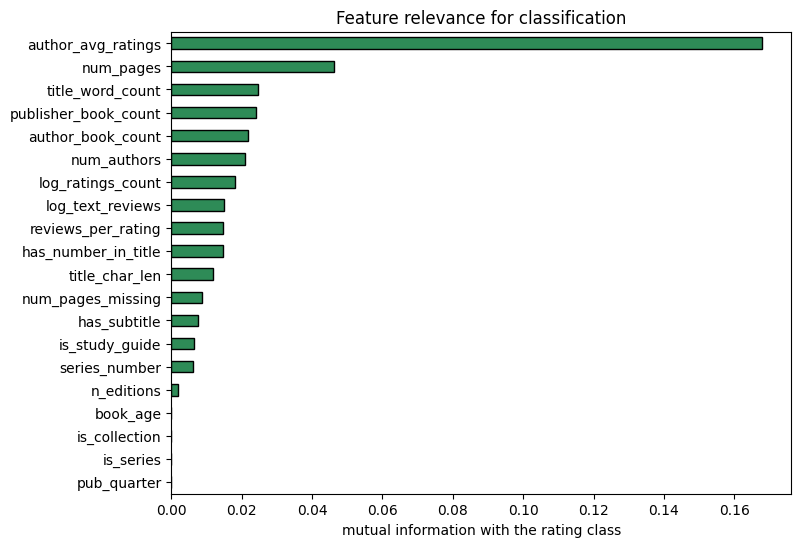

In [64]:
numeric_filled = X_train[numeric_features].fillna(X_train[numeric_features].median())
mi = mutual_info_classif(numeric_filled, y_train, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=numeric_features).sort_values(ascending=False)
print(mi_scores.round(4))
plt.figure(figsize=(8, 6))
mi_scores.sort_values().plot.barh(color="seagreen", edgecolor="black")
plt.xlabel("mutual information with the rating class")
plt.title("Feature relevance for classification")
plt.show()

In [65]:
majority_class = int(pd.Series(y_train).mode()[0])
baseline_pred = np.full(len(y_test), majority_class)
print("most common class:", class_names[majority_class])
print("baseline accuracy always predicting the most common class:", round(accuracy_score(y_test, baseline_pred), 4))

most common class: low rating
baseline accuracy always predicting the most common class: 0.3401


In [66]:
results = []

In [67]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("Logistic Regression   accuracy", round(scores.mean(), 4))
results.append(["LogisticRegression", scores.mean(), scores.std()])

Logistic Regression   accuracy 0.5298


In [68]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=25))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("KNN   accuracy", round(scores.mean(), 4))
results.append(["KNN", scores.mean(), scores.std()])

KNN   accuracy 0.5041


In [69]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("Decision Tree   accuracy", round(scores.mean(), 4))
results.append(["DecisionTree", scores.mean(), scores.std()])

Decision Tree   accuracy 0.4876


In [70]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("Random Forest   accuracy", round(scores.mean(), 4))
results.append(["RandomForest", scores.mean(), scores.std()])

Random Forest   accuracy 0.5372


In [71]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("Extra Trees   accuracy", round(scores.mean(), 4))
results.append(["ExtraTrees", scores.mean(), scores.std()])

Extra Trees   accuracy 0.5292


In [72]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("Hist Gradient Boosting   accuracy", round(scores.mean(), 4))
results.append(["HistGradientBoosting", scores.mean(), scores.std()])

Hist Gradient Boosting   accuracy 0.5263


In [73]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", AdaBoostClassifier(random_state=RANDOM_STATE))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("AdaBoost   accuracy", round(scores.mean(), 4))
results.append(["AdaBoost", scores.mean(), scores.std()])

AdaBoost   accuracy 0.5303


In [74]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", SVC(C=1.0))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("SVC   accuracy", round(scores.mean(), 4))
results.append(["SVC", scores.mean(), scores.std()])

SVC   accuracy 0.5349


In [75]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("XGBoost   accuracy", round(scores.mean(), 4))
results.append(["XGBoost", scores.mean(), scores.std()])

XGBoost   accuracy 0.543


In [76]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", LGBMClassifier(n_estimators=300, learning_rate=0.05, n_jobs=-1, verbose=-1))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("LightGBM   accuracy", round(scores.mean(), 4))
results.append(["LightGBM", scores.mean(), scores.std()])

LightGBM   accuracy 0.5323


In [77]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=RANDOM_STATE))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("CatBoost   accuracy", round(scores.mean(), 4))
results.append(["CatBoost", scores.mean(), scores.std()])

CatBoost   accuracy 0.5498


In [78]:
model = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, early_stopping=True, random_state=RANDOM_STATE))])
scores = cross_val_score(model, X_train, y_train, cv=class_cv, scoring="accuracy")
print("Neural Network   accuracy", round(scores.mean(), 4))
results.append(["NeuralNetwork", scores.mean(), scores.std()])

Neural Network   accuracy 0.5318


In [79]:
comparison = pd.DataFrame(results, columns=["model", "accuracy", "accuracy_std"]).set_index("model").sort_values("accuracy", ascending=False)
comparison.round(4)

,accuracy,accuracy_std
model,,
CatBoost,0.5498,0.0044
XGBoost,0.5430,0.0069
RandomForest,0.5372,0.0060
SVC,0.5349,0.0055
LightGBM,0.5323,0.0020
NeuralNetwork,0.5318,0.0059
AdaBoost,0.5303,0.0068
LogisticRegression,0.5298,0.0064
ExtraTrees,0.5292,0.0037


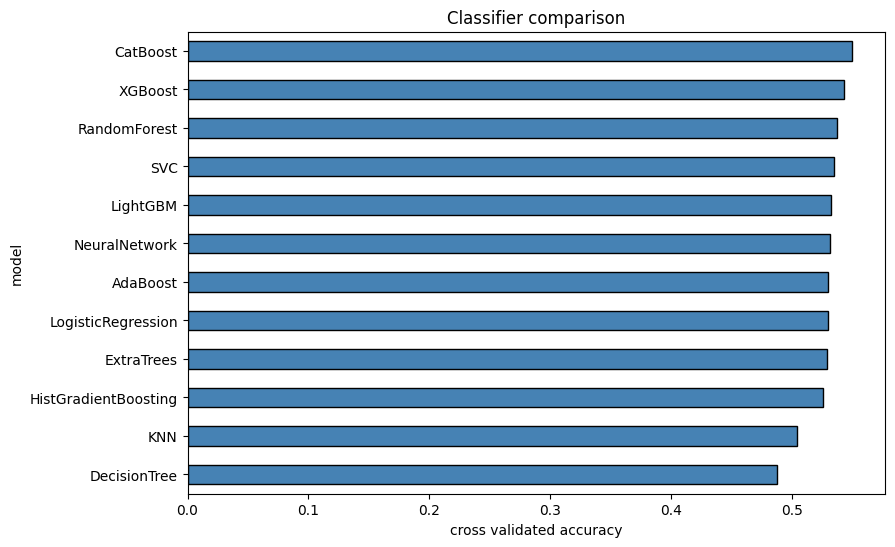

In [80]:
plt.figure(figsize=(9, 6))
comparison["accuracy"].sort_values().plot.barh(color="steelblue", edgecolor="black")
plt.xlabel("cross validated accuracy")
plt.title("Classifier comparison")
plt.show()

In [81]:
parameter_grid = {
    "model__depth": [4, 6],
    "model__learning_rate": [0.03, 0.06],
}
catboost_pipeline = Pipeline([("prep", preprocessor), ("scaler", StandardScaler()), ("model", CatBoostClassifier(iterations=400, verbose=0, random_state=RANDOM_STATE))])
grid = GridSearchCV(catboost_pipeline, parameter_grid, cv=class_cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
print("best parameters:", grid.best_params_)
print("best cross validated accuracy:", round(grid.best_score_, 4))

best parameters: {'model__depth': 6, 'model__learning_rate': 0.03}
best cross validated accuracy: 0.5494


In [82]:
best_model = grid.best_estimator_
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)
print("tuned CatBoost classifier")
print("test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("test AUC one vs rest:", round(roc_auc_score(y_test, test_proba, multi_class="ovr"), 4))

tuned CatBoost classifier
test accuracy: 0.5797
test AUC one vs rest: 0.7638


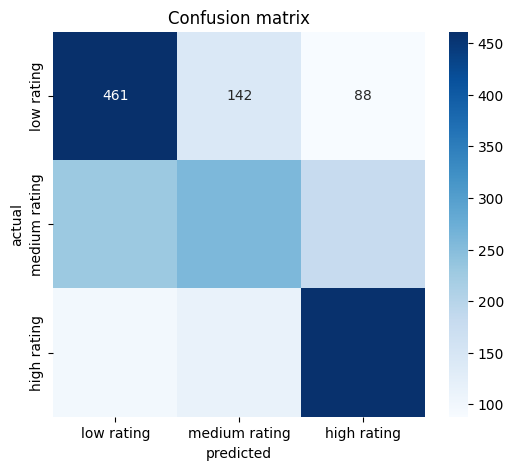

In [83]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion matrix")
plt.show()

In [84]:
print(classification_report(y_test, test_pred, target_names=class_names))

               precision    recall  f1-score   support

   low rating       0.58      0.67      0.62       691
medium rating       0.50      0.39      0.44       669
  high rating       0.63      0.68      0.66       672

     accuracy                           0.58      2032
    macro avg       0.57      0.58      0.57      2032
 weighted avg       0.57      0.58      0.57      2032



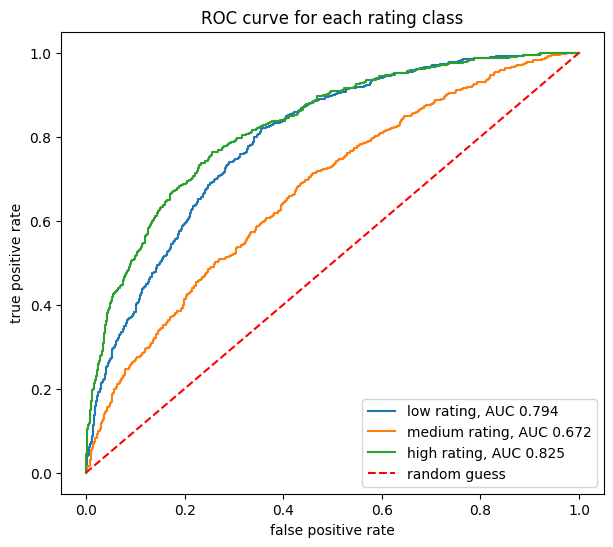

In [85]:
y_test_binary = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(7, 6))
fpr0, tpr0, t0 = roc_curve(y_test_binary[:, 0], test_proba[:, 0])
plt.plot(fpr0, tpr0, label="low rating, AUC " + str(round(roc_auc_score(y_test_binary[:, 0], test_proba[:, 0]), 3)))
fpr1, tpr1, t1 = roc_curve(y_test_binary[:, 1], test_proba[:, 1])
plt.plot(fpr1, tpr1, label="medium rating, AUC " + str(round(roc_auc_score(y_test_binary[:, 1], test_proba[:, 1]), 3)))
fpr2, tpr2, t2 = roc_curve(y_test_binary[:, 2], test_proba[:, 2])
plt.plot(fpr2, tpr2, label="high rating, AUC " + str(round(roc_auc_score(y_test_binary[:, 2], test_proba[:, 2]), 3)))
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="random guess")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve for each rating class")
plt.legend()
plt.show()

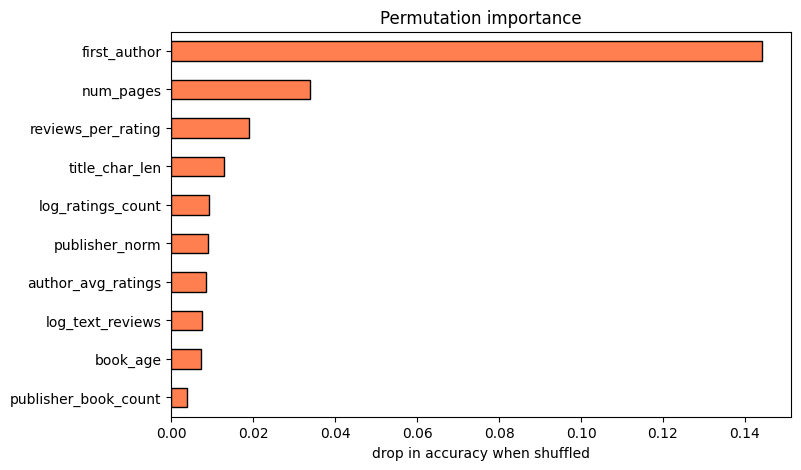

In [86]:
importance = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring="accuracy")
importance_scores = pd.Series(importance.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importance_scores.head(10).sort_values().plot.barh(color="coral", edgecolor="black")
plt.xlabel("drop in accuracy when shuffled")
plt.title("Permutation importance")
plt.show()

In [87]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(RANDOM_STATE)
nn_preprocessor = Pipeline([("prep", preprocessor), ("scaler", StandardScaler())])
X_train_dense = nn_preprocessor.fit_transform(X_train, y_train)
X_test_dense = nn_preprocessor.transform(X_test)
print("number of input features for the network:", X_train_dense.shape[1])

number of input features for the network: 32


In [88]:
deep_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_dense.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(3, activation="softmax"),
])
deep_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = deep_model.fit(X_train_dense, y_train, validation_split=0.2, epochs=30, batch_size=256, verbose=0)
print("deep learning training finished after", len(history.history["loss"]), "epochs")

deep learning training finished after 30 epochs


In [89]:
nn_proba = deep_model.predict(X_test_dense, verbose=0)
nn_pred = nn_proba.argmax(axis=1)
print("deep learning test accuracy:", round(accuracy_score(y_test, nn_pred), 4))
print("deep learning test AUC one vs rest:", round(roc_auc_score(y_test, nn_proba, multi_class="ovr"), 4))

deep learning test accuracy: 0.5723
deep learning test AUC one vs rest: 0.7558


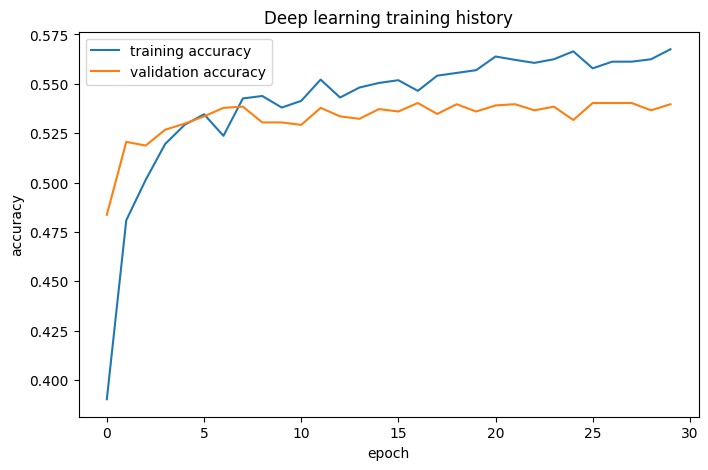

In [90]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="training accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Deep learning training history")
plt.legend()
plt.show()

In [91]:
print("SUMMARY OF THE CLASSIFICATION TASK")
print("three balanced classes built from the rating: low, medium and high")
print("baseline accuracy always predicting the most common class:", round(accuracy_score(y_test, baseline_pred), 3))
print("best classical model test accuracy                       :", round(accuracy_score(y_test, test_pred), 3))
print("deep learning test accuracy                              :", round(accuracy_score(y_test, nn_pred), 3))
print()
print("high rated and low rated books are separated reasonably well")
print("the middle class is the hardest because its ratings overlap with both neighbours")
print("just like the regression model, the strongest signal is the identity of the author")

SUMMARY OF THE CLASSIFICATION TASK
three balanced classes built from the rating: low, medium and high
baseline accuracy always predicting the most common class: 0.34
best classical model test accuracy                       : 0.58
deep learning test accuracy                              : 0.572

high rated and low rated books are separated reasonably well
the middle class is the hardest because its ratings overlap with both neighbours
just like the regression model, the strongest signal is the identity of the author
